# Pipeline unificado T1 → T8

Notebook integrado com os módulos dos dois Colabs, já organizado na ordem **T1 até T8**.

**Arquivos esperados no Colab:**
- `Finnish407.csv`
- `maxwell.arff`

Se os arquivos não estiverem na pasta atual do Colab, faça o upload antes de rodar o T1.

## Como este Colab responde ao comentário da aula

Este notebook deixa explícito o fluxo do ensemble:

**1. Geração**: cria um pool de regressão com modelos diversos e independentes, usando treino/validação no holdout 70/30.  
**2. Seleção**: aplica seleção estática com GA e seleção dinâmica com k-NN local.  
**3. Combinação**: junta as saídas dos modelos selecionados por média simples. Aqui a combinação é **não treinável**.

Observação importante: neste Colab eu removi modelos que já são ensembles como base do pool, para evitar a mistura sugerida no comentário da aula.

## 0. Instalação de dependências

In [ ]:
# Dependências padrão do Colab
print("✅ Dependências prontas")

✅ Dependências prontas


## Configuração geral

In [ ]:
import os
import json
import re
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.io import arff
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.30
DATA_DIR = "data"
MODELS_DIR = "models"
RESULTS_DIR = "results"

for d in [DATA_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Imports e pastas configurados")

✅ Imports e pastas configurados


## T1 — Pipeline de Dados & Pré-processamento

Carrega os datasets reais `Finnish407.csv` e `maxwell.arff`, aplica holdout 70/30, realiza MinMax scaling e salva os arquivos já prontos para as próximas etapas.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T1 — Pipeline de Dados & Pré-processamento
# ═══════════════════════════════════════════════════════════

import os
import re
import json
import numpy as np
import pandas as pd

from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# Configurações
# ---------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.30

DATA_DIR = "data_pool"
os.makedirs(DATA_DIR, exist_ok=True)

# ---------------------------------------------------------
# Utilitários
# ---------------------------------------------------------
def _normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).lower().strip())

def _ensure_input_file(path):
    if os.path.exists(path):
        return

    try:
        from google.colab import files

        print(f"\nArquivo '{path}' não encontrado.")
        print("Faça upload agora:\n")

        uploaded = files.upload()

        print("\nArquivos enviados:")
        print(list(uploaded.keys()))

    except Exception:
        raise FileNotFoundError(
            f"Arquivo '{path}' não encontrado."
        )

# ---------------------------------------------------------
# Carregamento Finnish
# ---------------------------------------------------------
def load_finnish_csv(path="Finnish407.csv"):

    _ensure_input_file(path)

    df = pd.read_csv(path)

    print(f"✅ Finnish carregado: {df.shape}")

    return df

# ---------------------------------------------------------
# Carregamento Maxwell
# ---------------------------------------------------------
def load_maxwell_arff(path="maxwell.arff"):

    _ensure_input_file(path)

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, (bytes, bytearray))
                else x
            )

        df[col] = pd.to_numeric(df[col], errors="ignore")

    print(f"✅ Maxwell carregado: {df.shape}")

    return df

# ---------------------------------------------------------
# Descobre automaticamente a coluna alvo
# ---------------------------------------------------------
def find_target(df, candidates):

    normalized = {
        _normalize_name(c): c
        for c in df.columns
    }

    for cand in candidates:

        key = _normalize_name(cand)

        if key in normalized:
            return normalized[key]

    return None

# ---------------------------------------------------------
# Pré-processamento
# ---------------------------------------------------------
def preprocess(df, target_candidates, dataset_name):

    print(f"\n[T1] Pré-processando {dataset_name}...")

    target_col = find_target(df, target_candidates)

    if target_col is None:

        print("\nColunas disponíveis:")
        print(df.columns.tolist())

        raise ValueError(
            f"Nenhuma coluna alvo encontrada para {dataset_name}"
        )

    print(f"  → Target encontrada: {target_col}")

    df_work = df.copy()

    # converte tudo para numérico
    for col in df_work.columns:
        df_work[col] = pd.to_numeric(
            df_work[col],
            errors="coerce"
        )

    # remove colunas totalmente vazias
    df_work = df_work.dropna(
        axis=1,
        how="all"
    )

    # remove linhas com NaN
    df_work = df_work.dropna().reset_index(drop=True)

    feature_names = [
        c for c in df_work.columns
        if c != target_col
    ]

    if len(feature_names) == 0:
        raise ValueError(
            f"Nenhuma feature encontrada em {dataset_name}"
        )

    print(f"  → Features utilizadas: {len(feature_names)}")
    print(f"  → Amostras válidas: {len(df_work)}")

    X = df_work[feature_names].values
    y = df_work[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_sc = scaler_X.fit_transform(X_train)
    X_test_sc = scaler_X.transform(X_test)

    y_train_sc = scaler_y.fit_transform(
        y_train.reshape(-1, 1)
    ).ravel()

    y_test_sc = scaler_y.transform(
        y_test.reshape(-1, 1)
    ).ravel()

    print(
        f"  → Treino: {X_train_sc.shape} | Teste: {X_test_sc.shape}"
    )

    return {
        "X_train": X_train_sc,
        "X_test": X_test_sc,
        "y_train": y_train_sc,
        "y_test": y_test_sc,
        "y_train_raw": y_train,
        "y_test_raw": y_test,
        "feature_names": feature_names,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "n_train": X_train_sc.shape[0],
        "n_test": X_test_sc.shape[0],
        "n_features": X_train_sc.shape[1],
        "target_name": target_col,
    }

# ---------------------------------------------------------
# Salva splits
# ---------------------------------------------------------
def save_splits(splits, dataset_name):

    prefix = os.path.join(
        DATA_DIR,
        dataset_name
    )

    np.save(
        f"{prefix}_X_train.npy",
        splits["X_train"]
    )

    np.save(
        f"{prefix}_X_test.npy",
        splits["X_test"]
    )

    np.save(
        f"{prefix}_y_train.npy",
        splits["y_train"]
    )

    np.save(
        f"{prefix}_y_test.npy",
        splits["y_test"]
    )

    pd.DataFrame(
        splits["X_train"],
        columns=splits["feature_names"]
    ).to_csv(
        f"{prefix}_train.csv",
        index=False
    )

    pd.DataFrame(
        splits["X_test"],
        columns=splits["feature_names"]
    ).to_csv(
        f"{prefix}_test.csv",
        index=False
    )

    print(f"  → Arquivos salvos: {prefix}_*")

# ---------------------------------------------------------
# Contrato de interface
# ---------------------------------------------------------
def save_pool_metadata(
    splits_finnish,
    splits_maxwell
):

    meta = {
        "contract_version": "1.0",
        "datasets": {
            "finnish": {
                "n_train": splits_finnish["n_train"],
                "n_test": splits_finnish["n_test"],
                "n_features": splits_finnish["n_features"],
                "target": splits_finnish["target_name"],
                "feature_names": splits_finnish["feature_names"]
            },
            "maxwell": {
                "n_train": splits_maxwell["n_train"],
                "n_test": splits_maxwell["n_test"],
                "n_features": splits_maxwell["n_features"],
                "target": splits_maxwell["target_name"],
                "feature_names": splits_maxwell["feature_names"]
            }
        }
    }

    path = os.path.join(
        DATA_DIR,
        "pool_metadata.json"
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            meta,
            f,
            indent=2,
            ensure_ascii=False
        )

    print(f"\n[T1] Contrato salvo: {path}")

    return meta

# ---------------------------------------------------------
# EXECUÇÃO
# ---------------------------------------------------------
print("=" * 60)
print(" T1 — Pipeline de Dados & Pré-processamento")
print("=" * 60)

df_finnish = load_finnish_csv("Finnish407.csv")
df_maxwell = load_maxwell_arff("maxwell.arff")

# Possíveis nomes da variável alvo
FINNISH_TARGETS = [
    "Worksup",
    "Effort",
    "worksup",
    "effort"
]

MAXWELL_TARGETS = [
    "Effort",
    "effort"
]

splits_finnish = preprocess(
    df_finnish,
    FINNISH_TARGETS,
    "Finnish"
)

splits_maxwell = preprocess(
    df_maxwell,
    MAXWELL_TARGETS,
    "Maxwell"
)

save_splits(
    splits_finnish,
    "finnish"
)

save_splits(
    splits_maxwell,
    "maxwell"
)

t1_metadata = save_pool_metadata(
    splits_finnish,
    splits_maxwell
)

print("\n[T1] ✓ Pipeline concluído!")

print(
    f"Finnish → treino={splits_finnish['n_train']} "
    f"teste={splits_finnish['n_test']} "
    f"features={splits_finnish['n_features']}"
)

print(
    f"Maxwell → treino={splits_maxwell['n_train']} "
    f"teste={splits_maxwell['n_test']} "
    f"features={splits_maxwell['n_features']}"
)

 T1 — Pipeline de Dados & Pré-processamento
✅ Finnish carregado: (407, 46)
✅ Maxwell carregado: (62, 27)

[T1] Pré-processando Finnish...
  → Target encontrada: Worksup
  → Features utilizadas: 40
  → Amostras válidas: 407
  → Treino: (284, 40) | Teste: (123, 40)

[T1] Pré-processando Maxwell...
  → Target encontrada: Effort
  → Features utilizadas: 26
  → Amostras válidas: 62
  → Treino: (43, 26) | Teste: (19, 26)
  → Arquivos salvos: data_pool/finnish_*
  → Arquivos salvos: data_pool/maxwell_*

[T1] Contrato salvo: data_pool/pool_metadata.json

[T1] ✓ Pipeline concluído!
Finnish → treino=284 teste=123 features=40
Maxwell → treino=43 teste=19 features=26


## T2 — Geração do Pool de Modelos Base

Treina o pool de modelos base e gera a matriz gabarito para treino e teste.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T2 — Geração do Pool de Modelos Base
# ═══════════════════════════════════════════════════════════

def build_pool() -> dict:
    """Pool de regressão: modelos diversos, sem usar ensembles como base."""
    return {
        "SVR": SVR(kernel="rbf", C=10.0, gamma="scale"),
        "MLP": MLPRegressor(hidden_layer_sizes=(64,), activation="relu",
                           learning_rate_init=0.01, max_iter=800,
                           random_state=RANDOM_STATE),
        "kNN": KNeighborsRegressor(n_neighbors=5),
        "DT":  DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
        "LR":  LinearRegression(),
        "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "Lasso": Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE),
    }

def matrix_mock(n_instances: int, m_models: int = 12, random_state: int = RANDOM_STATE) -> np.ndarray:
    """Matriz gabarito fictícia (fallback de autonomia)."""
    rng = np.random.default_rng(random_state)
    base = rng.uniform(0, 1, size=n_instances)
    noise = rng.normal(0, 0.15, size=(n_instances, m_models))
    return np.clip(base[:, None] + noise, 0, 1).astype(np.float64)

def train_pool(X_train, y_train, X_test, dataset_name):
    pool = build_pool()
    model_names = list(pool.keys())
    M, N_train, N_test = len(model_names), X_train.shape[0], X_test.shape[0]
    pm_train = np.zeros((N_train, M))
    pm_test = np.zeros((N_test, M))
    trained_models = {}

    print(f"\n[T2] Treinando pool para {dataset_name} ({M} modelos)...")
    model_dir = os.path.join(MODELS_DIR, f"{dataset_name}_pool")
    os.makedirs(model_dir, exist_ok=True)

    for i, (name, model) in enumerate(pool.items()):
        try:
            model.fit(X_train, y_train)
            pm_train[:, i] = np.clip(model.predict(X_train), 0, 1)
            pm_test[:, i] = np.clip(model.predict(X_test), 0, 1)
            trained_models[name] = model
            model_path = os.path.join(model_dir, f"{name}.joblib")
            joblib.dump(model, model_path)
            print(f"  [{i+1:02d}/{M}] {name:<5} ✓")
        except Exception as e:
            print(f"  [{i+1:02d}/{M}] {name:<5} ✗  ERRO: {e}")
            pm_train[:, i] = matrix_mock(N_train, 1, RANDOM_STATE + i).ravel()
            pm_test[:, i] = matrix_mock(N_test, 1, RANDOM_STATE + i + 100).ravel()

    return dict(
        models=trained_models,
        model_names=model_names,
        pred_matrix_train=pm_train,
        pred_matrix_test=pm_test,
        model_dir=model_dir,
    )

def save_artifacts(result, dataset_name, y_train, y_test):
    prefix = os.path.join(DATA_DIR, dataset_name)
    paths = {
        "train_matrix": f"{prefix}_pred_matrix_train.npy",
        "test_matrix":  f"{prefix}_pred_matrix_test.npy",
        "y_train":      f"{prefix}_y_train.npy",
        "y_test":       f"{prefix}_y_test.npy",
    }
    np.save(paths["train_matrix"], result["pred_matrix_train"])
    np.save(paths["test_matrix"], result["pred_matrix_test"])
    np.save(paths["y_train"], y_train)
    np.save(paths["y_test"], y_test)
    print(f"  → Matriz treino: {result['pred_matrix_train'].shape} | Matriz teste: {result['pred_matrix_test'].shape}")
    return {
        **paths,
        "shape_train": list(result["pred_matrix_train"].shape),
        "shape_test": list(result["pred_matrix_test"].shape),
    }

print("=" * 60)
print("  T2 — Geração do Pool de Modelos Base")
print("=" * 60)

t2_registry = {}
for dname, sf in [("finnish", splits_finnish), ("maxwell", splits_maxwell)]:
    result = train_pool(sf["X_train"], sf["y_train"], sf["X_test"], dname)
    info = save_artifacts(result, dname, sf["y_train"], sf["y_test"])
    info["model_dir"] = result["model_dir"]
    info["n_models"] = len(result["model_names"])
    t2_registry[dname] = (info, result)

registry = {
    "contract_version": "1.0",
    "model_siglas": t2_registry["finnish"][1]["model_names"],
    "datasets": {k: v[0] for k, v in t2_registry.items()},
    "matrix_format": {
        "shape": "(N_instances, M_models)",
        "dtype": "float64",
        "values": "predições MinMax-normalizadas [0,1]",
    },
}
reg_path = os.path.join(DATA_DIR, "pool_registry.json")
with open(reg_path, "w", encoding="utf-8") as f:
    json.dump(registry, f, indent=2, ensure_ascii=False)

print(f"\n[T2] Contrato de interface salvo: {reg_path}")
print("[T2] ✓ Pool de modelos gerado com sucesso!")

  T2 — Geração do Pool de Modelos Base

[T2] Treinando pool para finnish (8 modelos)...
  [01/8] SVR   ✓
  [02/8] MLP   ✓
  [03/8] kNN   ✓
  [04/8] DT    ✓
  [05/8] LR    ✓
  [06/8] Ridge ✓
  [07/8] Lasso ✓
  [08/8] ElasticNet ✓
  → Matriz treino: (284, 8) | Matriz teste: (123, 8)

[T2] Treinando pool para maxwell (8 modelos)...
  [01/8] SVR   ✓
  [02/8] MLP   ✓
  [03/8] kNN   ✓
  [04/8] DT    ✓
  [05/8] LR    ✓
  [06/8] Ridge ✓
  [07/8] Lasso ✓
  [08/8] ElasticNet ✓
  → Matriz treino: (43, 8) | Matriz teste: (19, 8)

[T2] Contrato de interface salvo: data_pool/pool_registry.json
[T2] ✓ Pool de modelos gerado com sucesso!


## T3 — SES-GA Mono-objetivo (Maximiza R²)

Implementação do algoritmo genético mono-objetivo.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T3 — SES-GA Mono-objetivo (R²)
# ═══════════════════════════════════════════════════════════

def r_squared(y_true, y_pred):
    """R² / COD — Equação 6 do artigo."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return -np.inf if ss_tot == 0 else float(1.0 - ss_res / ss_tot)

def pearson_r_squared(y_true, y_pred):
    """Pearson R² — fitness function do GA."""
    n = len(y_true)
    if n == 0:
        return -np.inf
    sa, sp = np.sum(y_true), np.sum(y_pred)
    sap = np.sum(y_true * y_pred)
    sa2, sp2 = np.sum(y_true**2), np.sum(y_pred**2)
    num = n * sap - sa * sp
    den = np.sqrt(max(n * sa2 - sa**2, 1e-12) * max(n * sp2 - sp**2, 1e-12))
    return 0.0 if den == 0 else float((num / den) ** 2)

def combine_predictions(pred_matrix, chromosome, weights=None):
    """Combinação dos modelos selecionados. Padrão: média simples (não treinável)."""
    active = np.where(np.array(chromosome, dtype=int) == 1)[0]
    if len(active) == 0:
        return np.mean(pred_matrix, axis=1)

    selected = pred_matrix[:, active]

    if weights is None:
        return np.mean(selected, axis=1)

    w = np.array(weights, dtype=float)
    w = w[active]
    if np.sum(w) == 0:
        return np.mean(selected, axis=1)
    w = w / np.sum(w)
    return selected @ w

def ensemble_predict(pred_matrix, chromosome):
    return combine_predictions(pred_matrix, chromosome)

def initialize_population(pop_size, n_models, rng):
    pop = rng.integers(0, 2, size=(pop_size, n_models)).astype(int)
    for i in range(pop_size):
        if pop[i].sum() == 0:
            pop[i, rng.integers(0, n_models)] = 1
    return pop

def evaluate_population(pop, pred_matrix, y_true):
    return np.array([pearson_r_squared(y_true, ensemble_predict(pred_matrix, c)) for c in pop])

def tournament_selection(pop, fitness, n_select, tournament_size, rng):
    selected = np.zeros((n_select, pop.shape[1]), dtype=int)
    for i in range(n_select):
        cands = rng.integers(0, len(pop), size=tournament_size)
        selected[i] = pop[cands[np.argmax(fitness[cands])]]
    return selected

def single_point_crossover(p1, p2, crossover_rate, rng):
    if rng.random() < crossover_rate:
        pt = rng.integers(1, len(p1))
        return np.concatenate([p1[:pt], p2[pt:]]), np.concatenate([p2[:pt], p1[pt:]])
    return p1.copy(), p2.copy()

def bit_flip_mutation(chrom, mutation_rate, rng):
    mutant = chrom.copy()
    mutant[rng.random(size=len(mutant)) < mutation_rate] ^= 1
    if mutant.sum() == 0:
        mutant[rng.integers(0, len(mutant))] = 1
    return mutant

def run_ses_ga(pred_matrix_train, y_train, pred_matrix_test=None, y_test=None,
               pop_size=50, n_generations=100, crossover_rate=0.8,
               mutation_rate=0.02, tournament_size=3, elitism=2,
               random_state=RANDOM_STATE, verbose=True):
    rng = np.random.default_rng(random_state)
    n_models = pred_matrix_train.shape[1]
    t0 = time.time()

    pop = initialize_population(pop_size, n_models, rng)
    fitness = evaluate_population(pop, pred_matrix_train, y_train)

    best_chrom = pop[np.argmax(fitness)].copy()
    best_fitness = float(fitness.max())
    history, stagnation = [], 0

    if verbose:
        print(f"\n  [SES-GA] pop={pop_size}, ger={n_generations}, M={n_models}")
        print(f"  {'Ger':>5} | {'Melhor R²':>10} | {'Média R²':>10} | {'#Mod':>6}")
        print("  " + "-" * 40)

    for gen in range(n_generations):
        elite = pop[np.argsort(fitness)[-elitism:]].copy()
        selected = tournament_selection(pop, fitness, pop_size - elitism, tournament_size, rng)

        offspring = []
        for i in range(0, len(selected) - 1, 2):
            c1, c2 = single_point_crossover(selected[i], selected[i + 1], crossover_rate, rng)
            offspring += [bit_flip_mutation(c1, mutation_rate, rng), bit_flip_mutation(c2, mutation_rate, rng)]
        if len(offspring) < len(selected):
            offspring.append(bit_flip_mutation(selected[-1], mutation_rate, rng))

        pop = np.vstack([elite, np.array(offspring[: pop_size - elitism])])
        fitness = evaluate_population(pop, pred_matrix_train, y_train)

        gen_best_idx = np.argmax(fitness)
        gen_best_fit = float(fitness[gen_best_idx])
        if gen_best_fit > best_fitness + 1e-12:
            best_fitness = gen_best_fit
            best_chrom = pop[gen_best_idx].copy()
            stagnation = 0
        else:
            stagnation += 1

        history.append({"gen": gen + 1, "best": gen_best_fit, "mean": float(np.mean(fitness)), "n_models": int(pop[gen_best_idx].sum())})

        if verbose and (gen % 10 == 0 or gen == n_generations - 1):
            print(f"  {gen + 1:5d} | {gen_best_fit:10.6f} | {np.mean(fitness):10.6f} | {int(pop[gen_best_idx].sum()):6d}")

        if stagnation >= 20:
            if verbose:
                print(f"  → Parada antecipada na geração {gen + 1}")
            break

    selected_idx = np.where(best_chrom == 1)[0]
    if len(selected_idx) == 0:
        selected_idx = np.array([int(np.argmax(best_chrom))])

    y_pred_train = ensemble_predict(pred_matrix_train, best_chrom)
    r2_train = r_squared(y_train, y_pred_train)

    r2_test = None
    if pred_matrix_test is not None and y_test is not None:
        y_pred_test = ensemble_predict(pred_matrix_test, best_chrom)
        r2_test = r_squared(y_test, y_pred_test)

    runtime = time.time() - t0

    if verbose:
        print(f"\n  [SES-GA] Melhor cromossomo: {best_chrom.tolist()}")
        print(f"  [SES-GA] Modelos selecionados: {selected_idx.tolist()}")
        print(f"  [SES-GA] R² treino (fitness): {best_fitness:.6f} | R² treino real: {r2_train:.6f}")
        if r2_test is not None:
            print(f"  [SES-GA] R² teste: {r2_test:.6f}")
        print(f"  [SES-GA] Tempo: {runtime:.2f}s")

    return dict(
        best_chromosome=best_chrom.tolist(),
        best_fitness_train=best_fitness,
        best_r2_train=r2_train,
        best_r2_test=r2_test,
        selected_models_idx=selected_idx.tolist(),
        n_models_selected=len(selected_idx),
        history=history,
        runtime_s=runtime,
        hyperparams=dict(
            pop_size=pop_size, n_generations=n_generations,
            crossover_rate=crossover_rate, mutation_rate=mutation_rate,
            tournament_size=tournament_size, elitism=elitism,
            random_state=random_state,
        ),
    )

print("=" * 60)
print("  T3 — SES-GA Mono-objetivo (R²)")
print("=" * 60)

t3_results = {}
for dname in ["finnish", "maxwell"]:
    print(f"\n{'─'*50}\n  Dataset: {dname.upper()}\n{'─'*50}")

    train_path = os.path.join(DATA_DIR, f"{dname}_pred_matrix_train.npy")
    if os.path.exists(train_path):
        pm_train = np.load(train_path)
        pm_test = np.load(os.path.join(DATA_DIR, f"{dname}_pred_matrix_test.npy"))
        y_tr = np.load(os.path.join(DATA_DIR, f"{dname}_y_train.npy"))
        y_te = np.load(os.path.join(DATA_DIR, f"{dname}_y_test.npy"))
        print("  → Matrizes reais carregadas de T2.")
    else:
        n_tr, n_te = (283, 122) if dname == "finnish" else (43, 19)
        pm_train = matrix_mock(n_tr)
        pm_test = matrix_mock(n_te, random_state=RANDOM_STATE + 99)
        rng_t = np.random.default_rng(RANDOM_STATE)
        y_tr = rng_t.uniform(0, 1, n_tr)
        y_te = rng_t.uniform(0, 1, n_te)
        print("  → Usando matrizes MOCK.")

    result = run_ses_ga(pm_train, y_tr, pm_test, y_te)
    t3_results[dname] = result

    out = os.path.join(RESULTS_DIR, f"{dname}_ses_ga.json")
    with open(out, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
    print(f"  → Resultado salvo: {out}")

print("\n[T3] ✓ SES-GA concluído!")

  T3 — SES-GA Mono-objetivo (R²)

──────────────────────────────────────────────────
  Dataset: FINNISH
──────────────────────────────────────────────────
  → Matrizes reais carregadas de T2.

  [SES-GA] pop=50, ger=100, M=8
    Ger |  Melhor R² |   Média R² |   #Mod
  ----------------------------------------
      1 |   0.908029 |   0.870153 |      3
     11 |   0.910508 |   0.906060 |      2
     21 |   0.910508 |   0.906040 |      2
  → Parada antecipada na geração 23

  [SES-GA] Melhor cromossomo: [1, 0, 0, 1, 0, 0, 0, 0]
  [SES-GA] Modelos selecionados: [0, 3]
  [SES-GA] R² treino (fitness): 0.910508 | R² treino real: 0.889795
  [SES-GA] R² teste: 0.462631
  [SES-GA] Tempo: 0.12s
  → Resultado salvo: results/finnish_ses_ga.json

──────────────────────────────────────────────────
  Dataset: MAXWELL
──────────────────────────────────────────────────
  → Matrizes reais carregadas de T2.

  [SES-GA] pop=50, ger=100, M=8
    Ger |  Melhor R² |   Média R² |   #Mod
  --------------------

## T4 — SES-GA Multi-objetivo (R² × Parcimônia)

Extensão com NSGA-II simplificado.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T4 — SES-GA Multi-objetivo (R² × Parcimônia)
# ═══════════════════════════════════════════════════════════

def dominates(obj1, obj2):
    """obj1 domina obj2 (ambos maximizados)."""
    return bool(np.all(obj1 >= obj2) and np.any(obj1 > obj2))

def fast_non_dominated_sort(objectives):
    """Ordena em frentes de Pareto (NSGA-II)."""
    n = len(objectives)
    dom_count = np.zeros(n, dtype=int)
    dom_by = [[] for _ in range(n)]
    fronts = [[]]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(objectives[i], objectives[j]):
                dom_by[i].append(j)
            elif dominates(objectives[j], objectives[i]):
                dom_count[i] += 1
        if dom_count[i] == 0:
            fronts[0].append(i)

    fi = 0
    while fi < len(fronts) and fronts[fi]:
        nxt = []
        for i in fronts[fi]:
            for j in dom_by[i]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    nxt.append(j)
        fi += 1
        if nxt:
            fronts.append(nxt)
    return fronts

def crowding_distance(objectives, front):
    n = len(front)
    if n <= 2:
        return np.full(n, np.inf)
    fo = objectives[front]
    dist = np.zeros(n)
    for m in range(fo.shape[1]):
        order = np.argsort(fo[:, m])
        dist[order[0]] = dist[order[-1]] = np.inf
        rng_val = fo[order[-1], m] - fo[order[0], m]
        if rng_val == 0:
            continue
        for k in range(1, n - 1):
            dist[order[k]] += (fo[order[k + 1], m] - fo[order[k - 1], m]) / rng_val
    return dist

def evaluate_multi(pop, pred_matrix, y_true):
    """Objetivos: [R², -n_active/M] — ambos a maximizar."""
    n_models = pop.shape[1]
    objs = np.zeros((len(pop), 2))
    for i, chrom in enumerate(pop):
        y_pred = ensemble_predict(pred_matrix, chrom)
        objs[i, 0] = pearson_r_squared(y_true, y_pred)
        objs[i, 1] = -max(int(chrom.sum()), 1) / n_models
    return objs

def pareto_selection(pop, objectives, n_select):
    fronts = fast_non_dominated_sort(objectives)
    sel = []
    for front in fronts:
        if len(sel) + len(front) <= n_select:
            sel.extend(front)
        else:
            rem = n_select - len(sel)
            cd = crowding_distance(objectives, front)
            sel.extend([idx for _, idx in sorted(zip(cd, front), reverse=True)[:rem]])
            break
    return pop[sel[:n_select]]

def run_ses_ga_multi(pred_matrix_train, y_train, pred_matrix_test=None, y_test=None,
                     pop_size=60, n_generations=100, crossover_rate=0.8,
                     mutation_rate=0.02, tournament_size=3, elitism=2,
                     random_state=RANDOM_STATE, verbose=True):
    rng = np.random.default_rng(random_state)
    n_models = pred_matrix_train.shape[1]
    t0 = time.time()

    pop = initialize_population(pop_size, n_models, rng)
    objs = evaluate_multi(pop, pred_matrix_train, y_train)
    hist_r2, hist_pareto = [], []

    if verbose:
        print(f"\n  [SES-GA-Multi] pop={pop_size}, ger={n_generations}, M={n_models}")
        print(f"  {'Ger':>5} | {'Melhor R²':>10} | {'|Pareto|':>9} | {'Min#Mod':>8}")
        print("  " + "-" * 42)

    for gen in range(n_generations):
        fronts = fast_non_dominated_sort(objs)
        pf_idx = fronts[0]
        best_r2g = float(np.max(objs[:, 0]))
        min_mods = int(np.min([-objs[i, 1] * n_models for i in pf_idx]))
        hist_r2.append(best_r2g)
        hist_pareto.append(len(pf_idx))

        if verbose and (gen % 10 == 0 or gen == n_generations - 1):
            print(f"  {gen + 1:5d} | {best_r2g:10.6f} | {len(pf_idx):9d} | {min_mods:8d}")

        n_elite = min(elitism, len(pf_idx))
        elite = pop[pf_idx[:n_elite]].copy()
        selected = pareto_selection(pop, objs, pop_size - n_elite)

        offspring = []
        for i in range(0, len(selected) - 1, 2):
            c1, c2 = single_point_crossover(selected[i], selected[i + 1], crossover_rate, rng)
            offspring += [bit_flip_mutation(c1, mutation_rate, rng), bit_flip_mutation(c2, mutation_rate, rng)]
        if len(offspring) < len(selected):
            offspring.append(bit_flip_mutation(selected[-1], mutation_rate, rng))

        pop = np.vstack([elite, np.array(offspring[: pop_size - n_elite])])
        objs = evaluate_multi(pop, pred_matrix_train, y_train)

    fronts = fast_non_dominated_sort(objs)
    pf_idx = fronts[0]
    pf_chroms = pop[pf_idx]
    pf_objs = objs[pf_idx]

    best_r2_idx = int(np.argmax(pf_objs[:, 0]))
    best_pars_idx = int(np.argmax(pf_objs[:, 1]))
    balance_score = pf_objs[:, 0] + pf_objs[:, 1]
    best_bal_idx = int(np.argmax(balance_score))

    def eval_test(chrom):
        if pred_matrix_test is None or y_test is None:
            return None
        return r_squared(y_test, ensemble_predict(pred_matrix_test, chrom))

    runtime = time.time() - t0

    if verbose:
        print(f"\n  [SES-GA-Multi] Frente Pareto final: {len(pf_idx)} soluções")
        print(f"  [SES-GA-Multi] Melhor R²      : {pf_objs[best_r2_idx, 0]:.6f}")
        print(f"  [SES-GA-Multi] Mais parcimonioso: {int(pf_chroms[best_pars_idx].sum())} modelos")
        print(f"  [SES-GA-Multi] Melhor equilíbrio: {int(pf_chroms[best_bal_idx].sum())} modelos")
        if pred_matrix_test is not None and y_test is not None:
            print(f"  [SES-GA-Multi] R² teste (best R²)      : {eval_test(pf_chroms[best_r2_idx]):.6f}")
            print(f"  [SES-GA-Multi] R² teste (parsimonioso) : {eval_test(pf_chroms[best_pars_idx]):.6f}")
            print(f"  [SES-GA-Multi] R² teste (equilíbrio)   : {eval_test(pf_chroms[best_bal_idx]):.6f}")
        print(f"  [SES-GA-Multi] Tempo: {runtime:.2f}s")

    return dict(
        pareto_front=pf_chroms.tolist(),
        pareto_objectives=pf_objs.tolist(),
        n_pareto_solutions=len(pf_idx),
        best_balanced=dict(
            chromosome=pf_chroms[best_bal_idx].tolist(),
            r2_train=float(pf_objs[best_bal_idx, 0]),
            n_models=int(pf_chroms[best_bal_idx].sum()),
            r2_test=eval_test(pf_chroms[best_bal_idx]),
        ),
        best_r2=dict(
            chromosome=pf_chroms[best_r2_idx].tolist(),
            r2_train=float(pf_objs[best_r2_idx, 0]),
            n_models=int(pf_chroms[best_r2_idx].sum()),
            r2_test=eval_test(pf_chroms[best_r2_idx]),
        ),
        best_parsimonious=dict(
            chromosome=pf_chroms[best_pars_idx].tolist(),
            r2_train=float(pf_objs[best_pars_idx, 0]),
            n_models=int(pf_chroms[best_pars_idx].sum()),
            r2_test=eval_test(pf_chroms[best_pars_idx]),
        ),
        history_r2=hist_r2,
        history_pareto_size=hist_pareto,
        runtime_s=runtime,
        hyperparams=dict(
            pop_size=pop_size, n_generations=n_generations,
            crossover_rate=crossover_rate, mutation_rate=mutation_rate,
            tournament_size=tournament_size, elitism=elitism,
            random_state=random_state,
        ),
    )

print("=" * 60)
print("  T4 — SES-GA Multi-objetivo (R² × Parcimônia)")
print("=" * 60)

t4_results = {}
for dname in ["finnish", "maxwell"]:
    print(f"\n{'─'*50}\n  Dataset: {dname.upper()}\n{'─'*50}")

    train_path = os.path.join(DATA_DIR, f"{dname}_pred_matrix_train.npy")
    if os.path.exists(train_path):
        pm_train = np.load(train_path)
        pm_test = np.load(os.path.join(DATA_DIR, f"{dname}_pred_matrix_test.npy"))
        y_tr = np.load(os.path.join(DATA_DIR, f"{dname}_y_train.npy"))
        y_te = np.load(os.path.join(DATA_DIR, f"{dname}_y_test.npy"))
        print("  → Matrizes reais carregadas de T2.")
    else:
        n_tr, n_te = (283, 122) if dname == "finnish" else (43, 19)
        pm_train = matrix_mock(n_tr)
        pm_test = matrix_mock(n_te, random_state=RANDOM_STATE + 99)
        rng_t = np.random.default_rng(RANDOM_STATE)
        y_tr = rng_t.uniform(0, 1, n_tr)
        y_te = rng_t.uniform(0, 1, n_te)
        print("  → Usando matrizes MOCK.")

    result = run_ses_ga_multi(pm_train, y_tr, pm_test, y_te)
    t4_results[dname] = result

    out_json = os.path.join(RESULTS_DIR, f"{dname}_ses_ga_multi.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False, default=lambda x: float(x) if isinstance(x, (np.floating,)) else int(x) if isinstance(x, (np.integer,)) else x)
    print(f"  → JSON salvo: {out_json}")

    pareto_arr = np.array(result["pareto_front"])
    out_npy = os.path.join(RESULTS_DIR, f"{dname}_pareto_front.npy")
    np.save(out_npy, pareto_arr)
    print(f"  → Frente de Pareto salva: {out_npy}  shape={pareto_arr.shape}")

print("\n[T4] ✓ SES-GA Multi-objetivo concluído!")

  T4 — SES-GA Multi-objetivo (R² × Parcimônia)

──────────────────────────────────────────────────
  Dataset: FINNISH
──────────────────────────────────────────────────
  → Matrizes reais carregadas de T2.

  [SES-GA-Multi] pop=60, ger=100, M=8
    Ger |  Melhor R² |  |Pareto| |  Min#Mod
  ------------------------------------------
      1 |   0.899686 |         3 |        2
     11 |   0.910508 |        14 |        1
     21 |   0.910508 |        19 |        1
     31 |   0.910508 |        26 |        1
     41 |   0.910508 |        18 |        1
     51 |   0.910508 |        20 |        1
     61 |   0.910508 |        23 |        1
     71 |   0.910508 |        19 |        1
     81 |   0.910508 |        26 |        1
     91 |   0.910508 |        30 |        1
    100 |   0.910508 |        27 |        1

  [SES-GA-Multi] Frente Pareto final: 26 soluções
  [SES-GA-Multi] Melhor R²      : 0.910508
  [SES-GA-Multi] Mais parcimonioso: 1 modelos
  [SES-GA-Multi] Melhor equilíbrio: 1 mode

## T5 — `des_dynamic.py` · Seleção Dinâmica de Ensemble (DES)

Seleciona, para cada instância de teste, os modelos mais competentes localmente.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T5 - des_dynamic.py
# ═══════════════════════════════════════════════════════════

class DynamicEnsembleSelector:
    """
    Seleção Dinâmica de Ensemble baseada em k-NN local.

    Parâmetros
    ----------
    k         : int   — número de vizinhos para a região de competência.
    threshold : float — fração dos melhores modelos a selecionar (ex.: 0.3 = top 30%).
    """

    def __init__(self, k: int = 7, threshold: float = 0.3):
        self.k = k
        self.threshold = threshold
        self.X_train = None
        self.gabarito = None
        self.y_train = None
        self.n_models = None

    def fit(self, X_train: np.ndarray, gabarito: np.ndarray, y_train: np.ndarray):
        """
        X_train  : (N_treino, N_features)
        gabarito : (N_treino, M_modelos)
        y_train  : (N_treino,)
        """
        self.X_train = np.array(X_train, dtype=float)
        self.gabarito = np.array(gabarito, dtype=float)
        self.y_train = np.array(y_train, dtype=float)
        self.n_models = gabarito.shape[1]
        print(f"[DES] fit() | {self.X_train.shape[0]} instâncias treino | {self.n_models} modelos no pool")
        return self

    def _get_neighbors(self, x_query: np.ndarray) -> np.ndarray:
        """Retorna índices dos k vizinhos mais próximos de x_query."""
        diffs = self.X_train - x_query
        dists = np.sqrt(np.sum(diffs ** 2, axis=1))
        return np.argsort(dists)[: self.k]

    def _local_competence(self, neighbor_idx: np.ndarray) -> np.ndarray:
        """Retorna array (M_modelos,) com o MAE local de cada modelo."""
        y_local = self.y_train[neighbor_idx]
        preds_local = self.gabarito[neighbor_idx, :]
        return np.mean(np.abs(preds_local - y_local[:, np.newaxis]), axis=0)

    def predict_single(self, x_query: np.ndarray, model_predictions: np.ndarray) -> float:
        """
        x_query           : (N_features,)
        model_predictions : (M_modelos,) — predições de todos os modelos para esta instância
        """
        neighbor_idx = self._get_neighbors(x_query)
        local_errors = self._local_competence(neighbor_idx)
        n_select = max(1, int(np.ceil(self.n_models * self.threshold)))
        selected = np.argsort(local_errors)[:n_select]
        return float(np.mean(model_predictions[selected]))

    def predict(self, X_test: np.ndarray, pool_predictions: np.ndarray) -> np.ndarray:
        """
        X_test           : (N_teste, N_features)
        pool_predictions : (N_teste, M_modelos)
        """
        X_test = np.array(X_test, dtype=float)
        pool_predictions = np.array(pool_predictions, dtype=float)
        preds = np.array([
            self.predict_single(X_test[i], pool_predictions[i])
            for i in range(len(X_test))
        ])
        print(f"[DES] predict() | {len(preds)} instâncias | k={self.k} | top {self.threshold*100:.0f}% modelos")
        return preds

print("✅ T5 — DynamicEnsembleSelector carregado")

✅ T5 — DynamicEnsembleSelector carregado


## T6 — `evaluator.py` · Engine de Extração de Métricas

Calcula sMAPE, MRE, MASE, NSE e COD (R²).

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T6 - evaluator.py
# ═══════════════════════════════════════════════════════════

def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return round(float(mean_squared_error(y_true, y_pred)), 6)

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return round(float(mean_absolute_error(y_true, y_pred)), 6)

def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Symmetric Mean Absolute Percentage Error (sMAPE)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    numerator = 2.0 * np.abs(y_true - y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    if not np.any(mask):
        return 0.0
    result = np.mean(numerator[mask] / denominator[mask]) * 100.0
    return round(float(result), 6)

def mre(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Relative Error (MRE)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    result = np.mean(np.abs(y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))
    return round(result, 6)

def mase(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Scaled Error (MASE)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    numerator = np.mean(np.abs(y_true - y_pred))
    denominator = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    if denominator == 0:
        return float("inf")
    return round(numerator / denominator, 6)

def nse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Nash-Sutcliffe Efficiency (NSE)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return float("nan")
    return round(1 - ss_res / ss_tot, 6)

def cod(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of Determination (COD / R²)."""
    return nse(y_true, y_pred)

def evaluate_all(y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Model") -> dict:
    """Calcula as métricas principais de regressão."""
    metrics = {
        "model": model_name,
        "MSE": mse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "COD": cod(y_true, y_pred),
        "MRE": mre(y_true, y_pred),
        "MASE": mase(y_true, y_pred),
        "NSE": nse(y_true, y_pred),
    }
    print(f"\n{'='*50}")
    print(f"  Métricas — {model_name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        if k != "model":
            print(f"  {k:<8}: {v}")
    print(f"{'='*50}")
    return metrics

print("✅ T6 — evaluator carregado")

✅ T6 — evaluator carregado


## T7 — `statistical_tests.py` · Validação Estatística de Demšar

Teste de Friedman, Bonferroni-Dunn e diagrama de diferença crítica.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  T7 - statistical_tests.py
# ═══════════════════════════════════════════════════════════

def friedman_test(results_matrix: np.ndarray, model_names: list) -> dict:
    """
    results_matrix : (K_datasets, N_modelos) — valores de erro (menor = melhor)
    model_names    : lista de strings
    """
    K, N = results_matrix.shape
    assert len(model_names) == N, "Número de nomes != número de colunas"

    ranks = np.zeros_like(results_matrix, dtype=float)
    for i in range(K):
        order = np.argsort(results_matrix[i])
        rank_row = np.empty_like(order, dtype=float)
        rank_row[order] = np.arange(1, N + 1)
        ranks[i] = rank_row

    avg_ranks = np.mean(ranks, axis=0)
    sum_sq_ranks = np.sum(avg_ranks ** 2)
    F_friedman = (12 * K / (N * (N + 1))) * (sum_sq_ranks - N * (N + 1) ** 2 / 4)
    p_value = 1 - stats.chi2.cdf(F_friedman, df=N - 1)

    print("\n" + "=" * 55)
    print("  TESTE DE FRIEDMAN")
    print("=" * 55)
    print(f"  Estatística de Friedman : {F_friedman:.4f}")
    print(f"  p-value                 : {p_value:.6f}")
    print(f"  Significativo (p<0.05)  : {'✅ SIM' if p_value < 0.05 else '❌ NÃO'}")
    print("\n  Ranks médios por modelo:")
    for name, rank in sorted(zip(model_names, avg_ranks), key=lambda x: x[1]):
        bar = "█" * int(rank * 3)
        print(f"    {name:<20} rank={rank:.3f}  {bar}")
    print("=" * 55)

    return {
        "F_statistic": F_friedman,
        "p_value": p_value,
        "avg_ranks": dict(zip(model_names, avg_ranks)),
        "rank_matrix": ranks,
        "significant": p_value < 0.05,
    }

def bonferroni_dunn_test(friedman_result: dict, control_model: str,
                         n_datasets: int, alpha: float = 0.05) -> dict:
    """Compara cada modelo contra o modelo de controle."""
    avg_ranks = friedman_result["avg_ranks"]
    N = len(avg_ranks)
    control_rank = avg_ranks[control_model]
    se = np.sqrt(N * (N + 1) / (6 * n_datasets))
    n_comp = N - 1
    z_alpha = stats.norm.ppf(1 - alpha / (2 * n_comp))
    cd = z_alpha * se

    print("\n" + "=" * 55)
    print(f"  POST-HOC: BONFERRONI-DUNN  (controle: {control_model})")
    print("=" * 55)
    print(f"  Diferença Crítica (CD) : {cd:.4f}")
    print(f"  z crítico (Bonferroni) : {z_alpha:.4f}")
    print(f"  alpha ajustado         : {alpha/n_comp:.5f}\n")

    results = {}
    for model, rank in avg_ranks.items():
        if model == control_model:
            continue
        diff = abs(rank - control_rank)
        significant = diff > cd
        symbol = (
            "✅ MELHOR" if (rank > control_rank and significant) else
            "❌ PIOR" if (rank < control_rank and significant) else
            "— empate"
        )
        print(f"  {control_model} vs {model:<18}  |diff|={diff:.3f}  CD={cd:.3f}  {symbol}")
        results[model] = {
            "rank_diff": diff,
            "significant": significant,
            "cd": cd,
            "control_better": rank > control_rank,
        }
    print("=" * 55)
    return results

def plot_cd_diagram(friedman_result: dict, control_model: str,
                    n_datasets: int, alpha: float = 0.05):
    """Gera e exibe o diagrama de Diferença Crítica."""
    avg_ranks = friedman_result["avg_ranks"]
    N = len(avg_ranks)
    se = np.sqrt(N * (N + 1) / (6 * n_datasets))
    n_comp = N - 1
    z_alpha = stats.norm.ppf(1 - alpha / (2 * n_comp))
    cd = z_alpha * se

    sorted_models = sorted(avg_ranks.items(), key=lambda x: x[1])
    names = [m[0] for m in sorted_models]
    ranks = [m[1] for m in sorted_models]

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.set_xlim(0.5, N + 0.5)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color="black", lw=1.5)

    for i, (name, rank) in enumerate(zip(names, ranks)):
        color = "#e74c3c" if name == control_model else "#2980b9"
        marker = "*" if name == control_model else "o"
        ms = 12 if name == control_model else 8
        ax.plot(rank, 0, marker, color=color, ms=ms, zorder=5)
        va = "bottom" if i % 2 == 0 else "top"
        offset = 0.18 if i % 2 == 0 else -0.18
        ax.text(rank, offset, f"{name}\n({rank:.2f})",
                ha="center", va=va, fontsize=7.5, color=color, fontweight="bold")

    ctrl_rank = avg_ranks[control_model]
    ax.annotate("", xy=(ctrl_rank + cd, 0.6), xytext=(ctrl_rank, 0.6),
                arrowprops=dict(arrowstyle="<->", color="#27ae60", lw=2.5))
    ax.text(ctrl_rank + cd / 2, 0.72, f"CD = {cd:.2f}",
            ha="center", fontsize=9, color="#27ae60", fontweight="bold")

    ax.set_title(f"Critical Difference Diagram — controle: {control_model}",
                 fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Rank médio  (menor = melhor)", fontsize=9)
    ax.set_yticks([])
    ax.spines[["left", "right", "top"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"[PLOT] Diagrama exibido | CD={cd:.4f}")

print("✅ T7 — statistical_tests carregado")

✅ T7 — statistical_tests carregado


## T8 — Integração final com os dados reais

Esta etapa usa os arquivos gerados em T1–T4 para avaliar:
- os modelos base,
- o conjunto estático (Static),
- o SES-GA mono-objetivo,
- o SES-GA multi-objetivo,
- e o DES.

Também monta uma matriz de erro para o teste estatístico.


  Integração real — FINNISH
[DES] fit() | 284 instâncias treino | 8 modelos no pool
[DES] predict() | 123 instâncias | k=7 | top 30% modelos

  Métricas — DES (finnish)
  MSE     : 0.02336
  MAE     : 0.063576
  sMAPE   : 55.493155
  COD     : 0.536006
  MRE     : 0.694603
  MASE    : 0.355564
  NSE     : 0.536006

  Métricas — Static (finnish)
  MSE     : 0.023006
  MAE     : 0.065134
  sMAPE   : 56.267063
  COD     : 0.543048
  MRE     : 0.943533
  MASE    : 0.364278
  NSE     : 0.543048

  Métricas — SES-GA (finnish)
  MSE     : 0.027055
  MAE     : 0.081409
  sMAPE   : 71.264639
  COD     : 0.462631
  MRE     : 1.792627
  MASE    : 0.455299
  NSE     : 0.462631

  Métricas — SES-GA Multi (finnish)
  MSE     : 0.032223
  MAE     : 0.080692
  sMAPE   : 61.496606
  COD     : 0.359979
  MRE     : 1.146274
  MASE    : 0.45129
  NSE     : 0.359979

  Integração real — MAXWELL
[DES] fit() | 43 instâncias treino | 8 modelos no pool
[DES] predict() | 19 instâncias | k=7 | top 30% modelos



,dataset,Static_MSE,Static_MAE,Static_sMAPE,Static_COD,SES-GA_MSE,SES-GA_MAE,SES-GA_sMAPE,SES-GA_COD,SES-GA_Multi_MSE,SES-GA_Multi_MAE,SES-GA_Multi_sMAPE,SES-GA_Multi_COD,DES_MSE,DES_MAE,DES_sMAPE,DES_COD
0,finnish,0.023006,0.065134,56.267063,0.543048,0.027055,0.081409,71.264639,0.462631,0.032223,0.080692,61.496606,0.359979,0.023360,0.063576,55.493155,0.536006
1,maxwell,0.080229,0.161757,61.941637,0.487517,0.049695,0.142243,66.546808,0.682564,0.056617,0.153595,85.671842,0.638348,0.061979,0.152679,72.186523,0.604097



Matriz de erro (sMAPE) para o teste estatístico:
            SVR     MLP     kNN      DT      LR   Ridge   Lasso  ElasticNet  \
Finnish  80.553  65.274  62.597  61.497  79.302  68.007  61.882      65.174   
Maxwell  77.980  84.481  71.844  85.672  68.037  72.026  68.880      70.755   

         Static  SES-GA  SES-GA Multi     DES  
Finnish  56.267  71.265        61.497  55.493  
Maxwell  61.942  66.547        85.672  72.187  

  TESTE DE FRIEDMAN
  Estatística de Friedman : 9.3846
  p-value                 : 0.586436
  Significativo (p<0.05)  : ❌ NÃO

  Ranks médios por modelo:
    Static               rank=1.500  ████
    Lasso                rank=4.500  █████████████
    DES                  rank=4.500  █████████████
    kNN                  rank=6.000  ██████████████████
    ElasticNet           rank=6.000  ██████████████████
    SES-GA               rank=6.000  ██████████████████
    DT                   rank=7.000  █████████████████████
    LR                   rank=7.000  █████

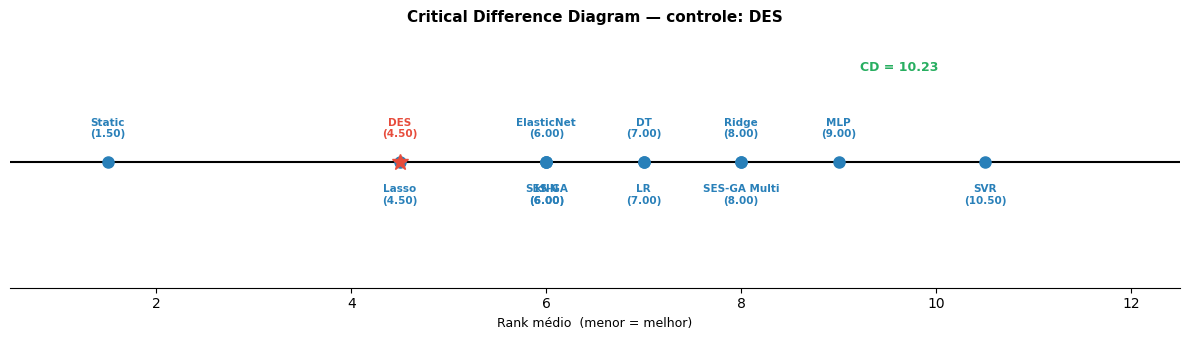

[PLOT] Diagrama exibido | CD=10.2311

[T8] Integração concluída com sucesso.


In [ ]:
# ── PASSO 1: carregar dados reais gerados nas etapas anteriores ──
def load_artifacts_for_dataset(dname: str):
    X_train = np.load(os.path.join(DATA_DIR, f"{dname}_X_train.npy"))
    X_test = np.load(os.path.join(DATA_DIR, f"{dname}_X_test.npy"))
    y_train = np.load(os.path.join(DATA_DIR, f"{dname}_y_train.npy"))
    y_test = np.load(os.path.join(DATA_DIR, f"{dname}_y_test.npy"))
    pred_train = np.load(os.path.join(DATA_DIR, f"{dname}_pred_matrix_train.npy"))
    pred_test = np.load(os.path.join(DATA_DIR, f"{dname}_pred_matrix_test.npy"))
    return X_train, X_test, y_train, y_test, pred_train, pred_test

def chrom_to_pred(pred_matrix: np.ndarray, chromosome: list[int] | np.ndarray) -> np.ndarray:
    return combine_predictions(pred_matrix, chromosome)

summary_rows = []
results_matrix_rows = []
method_names = None

for dname in ["finnish", "maxwell"]:
    print(f"\n{'='*60}")
    print(f"  Integração real — {dname.upper()}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test, pred_train, pred_test = load_artifacts_for_dataset(dname)

    # DES
    des = DynamicEnsembleSelector(k=7, threshold=0.3)
    des.fit(X_train, pred_train, y_train)
    y_pred_des = des.predict(X_test, pred_test)

    # Static
    y_pred_static = np.mean(pred_test, axis=1)

    # SES-GA mono
    ses_idx = np.array(t3_results[dname]["selected_models_idx"], dtype=int)
    y_pred_ses = np.mean(pred_test[:, ses_idx], axis=1) if len(ses_idx) else np.mean(pred_test, axis=1)

    # SES-GA multi
    best_bal_chrom = t4_results[dname]["best_balanced"]["chromosome"]
    y_pred_ses_multi = chrom_to_pred(pred_test, best_bal_chrom)

    # Métricas principais
    m_des = evaluate_all(y_test, y_pred_des, model_name=f"DES ({dname})")
    m_static = evaluate_all(y_test, y_pred_static, model_name=f"Static ({dname})")
    m_ses = evaluate_all(y_test, y_pred_ses, model_name=f"SES-GA ({dname})")
    m_ses_multi = evaluate_all(y_test, y_pred_ses_multi, model_name=f"SES-GA Multi ({dname})")

    # Base models
    base_names = t2_registry["finnish"][1]["model_names"]
    base_errors = [smape(y_test, pred_test[:, i]) for i in range(pred_test.shape[1])]

    row = base_errors + [
        smape(y_test, y_pred_static),
        smape(y_test, y_pred_ses),
        smape(y_test, y_pred_ses_multi),
        smape(y_test, y_pred_des),
    ]
    results_matrix_rows.append(row)

    if method_names is None:
        method_names = base_names + ["Static", "SES-GA", "SES-GA Multi", "DES"]

    summary_rows.append({
        "dataset": dname,
        "Static_MSE": mse(y_test, y_pred_static),
        "Static_MAE": mae(y_test, y_pred_static),
        "Static_sMAPE": m_static["sMAPE"],
        "Static_COD": cod(y_test, y_pred_static),

        "SES-GA_MSE": mse(y_test, y_pred_ses),
        "SES-GA_MAE": mae(y_test, y_pred_ses),
        "SES-GA_sMAPE": m_ses["sMAPE"],
        "SES-GA_COD": cod(y_test, y_pred_ses),

        "SES-GA_Multi_MSE": mse(y_test, y_pred_ses_multi),
        "SES-GA_Multi_MAE": mae(y_test, y_pred_ses_multi),
        "SES-GA_Multi_sMAPE": m_ses_multi["sMAPE"],
        "SES-GA_Multi_COD": cod(y_test, y_pred_ses_multi),

        "DES_MSE": mse(y_test, y_pred_des),
        "DES_MAE": mae(y_test, y_pred_des),
        "DES_sMAPE": m_des["sMAPE"],
        "DES_COD": cod(y_test, y_pred_des),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, "summary_real_datasets.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Resumo salvo em: {summary_path}")
display(summary_df)

results_matrix = np.array(results_matrix_rows, dtype=float)
print("\nMatriz de erro (sMAPE) para o teste estatístico:")
print(pd.DataFrame(results_matrix, columns=method_names, index=["Finnish", "Maxwell"]).round(3))

fr = friedman_test(results_matrix, method_names)

# Troque o controle abaixo se quiser comparar outro método
control_model = "DES"
if fr["significant"]:
    bd = bonferroni_dunn_test(fr, control_model=control_model, n_datasets=2)
else:
    print("\n[INFO] Friedman não significativo — post-hoc não aplicado.")

plot_cd_diagram(fr, control_model=control_model, n_datasets=2)
print("\n[T8] Integração concluída com sucesso.")